<a href="https://colab.research.google.com/github/shuangquan-li-con/ECON5200-37499-Applied-Data-Analytics-in-Economics/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 20: Time Series Diagnostics and Advanced Decomposition
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install fredapi statsmodels ruptures -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.7 MB/s eta 0:00:00


In [15]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Import libraries and set FRED API key
# -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.seasonal import seasonal_decompose, STL, MSTL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt

np.random.seed(42)

# Replace with your FRED API key (free at https://fred.stlouisfed.org/docs/api/api_key.html)
FRED_API_KEY = 'c3b49229ae543b42f8b6ba5671ac5aa6'
fred = Fred(api_key=FRED_API_KEY)

print('Libraries loaded. Ready to diagnose.')

Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Broken STL Decomposition (15 min)

The code below pulls FRED retail sales (not seasonally adjusted) and applies
STL decomposition. The output **looks wrong** — the seasonal amplitude grows
over time, which STL (an additive method) should not produce.

**Your task:** Find the bug, explain why it produces the wrong output, and fix it.

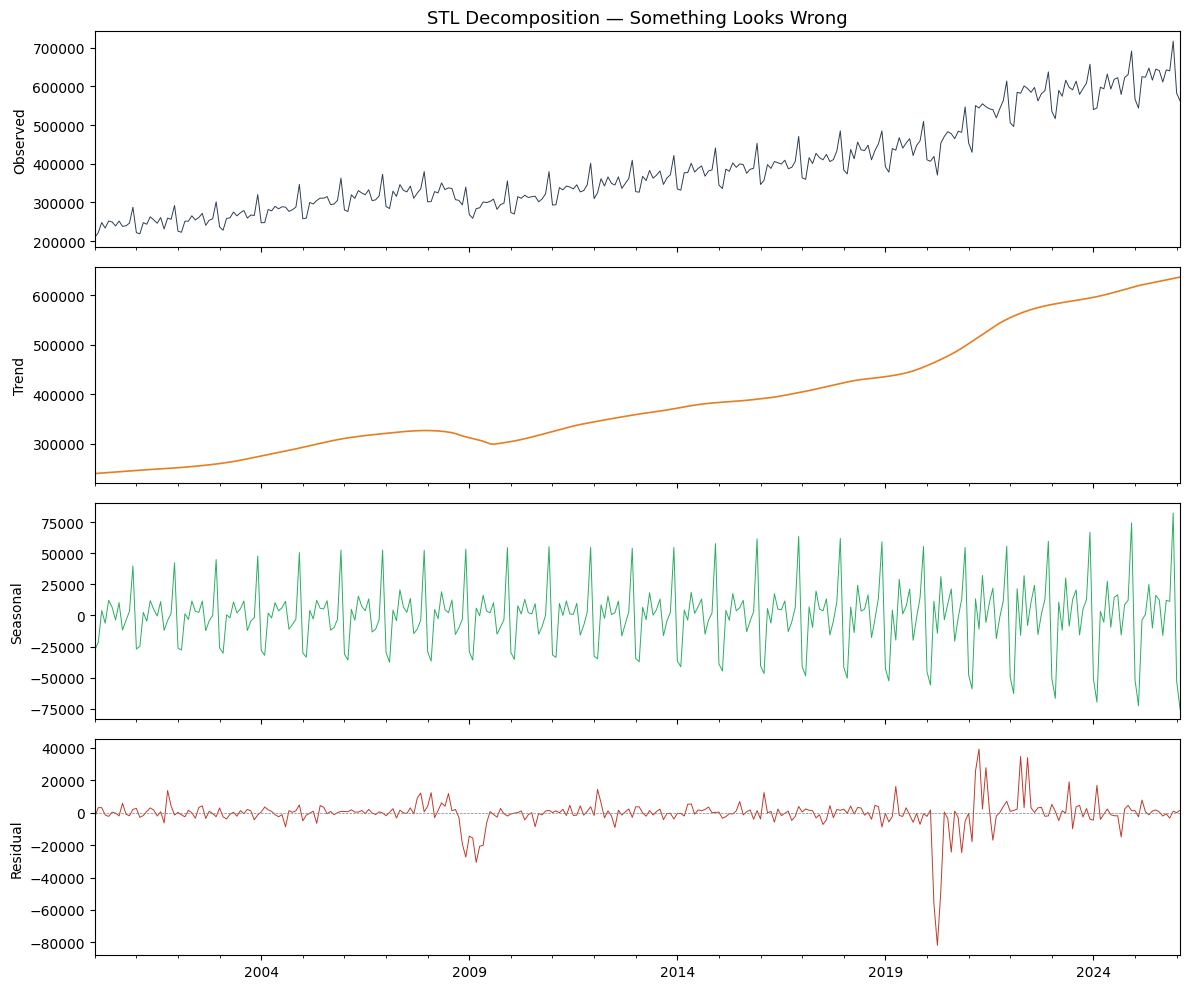

Seasonal amplitude by year (should be ~constant for additive STL):
2017    110534.8
2018    109659.5
2019    108141.1
2020    110688.7
2021    114825.7
2022    122586.4
2023    133678.4
2024    144192.4
2025    155045.5
2026     22723.9
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.33x
If this ratio >> 1, the additive assumption is violated.


In [16]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate error)
# Step 1: STL decomposition of retail sales
# -----------------------------------------------------------

retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'

# Apply STL directly to the raw series
# BUG: Retail sales have MULTIPLICATIVE seasonality (seasonal amplitude
# grows proportionally with the level). STL is an ADDITIVE decomposition.
# Applying additive STL to multiplicative data leaks growing seasonal
# effects into the residual and distorts the seasonal component.
stl_result = STL(retail, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_result.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — Something Looks Wrong', fontsize=13)

stl_result.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_result.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_result.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Diagnostic: seasonal amplitude should be roughly constant for additive STL.
# Compute the seasonal range per year to check.
seasonal_by_year = stl_result.seasonal.groupby(stl_result.seasonal.index.year)
annual_range = seasonal_by_year.apply(lambda x: x.max() - x.min())
print('Seasonal amplitude by year (should be ~constant for additive STL):')
print(annual_range.tail(10).round(1))
print(f'\nRatio of latest to earliest amplitude: {annual_range.iloc[-1] / annual_range.iloc[0]:.2f}x')
print('If this ratio >> 1, the additive assumption is violated.')

### YOUR DIAGNOSIS

1. **What is wrong?** The bug is that STL is being applied directly to the raw retail sales series. Retail sales usually have multiplicative seasonality, meaning the size of the seasonal swings grows as the level of the series grows. STL is an additive decomposition method, so applying it directly to raw multiplicative data violates the additive seasonal assumption.
2. **Why does this happen?** When seasonality is multiplicative, the seasonal variation is proportional to the level of the series rather than constant over time. If additive STL is applied to this kind of data, it cannot properly separate trend and seasonality. As a result, the estimated seasonal component appears to grow over time, and some of the changing scale leaks into the residual component. This makes the decomposition misleading.

3. **Fix the code below.** The correct fix is to take the natural log of the retail sales series first, and then apply STL to the logged series. The log transform converts multiplicative structure into approximately additive structure.
4. **What chapter concept does this error violate?**This error violates the distinction between **additive decomposition** and **multiplicative decomposition**.

**Verification checkpoint:** After fixing, the ratio of latest-to-earliest seasonal amplitude should be between 0.7 and 1.3 (roughly constant). If it is still > 2.0, you have not fixed the bug.

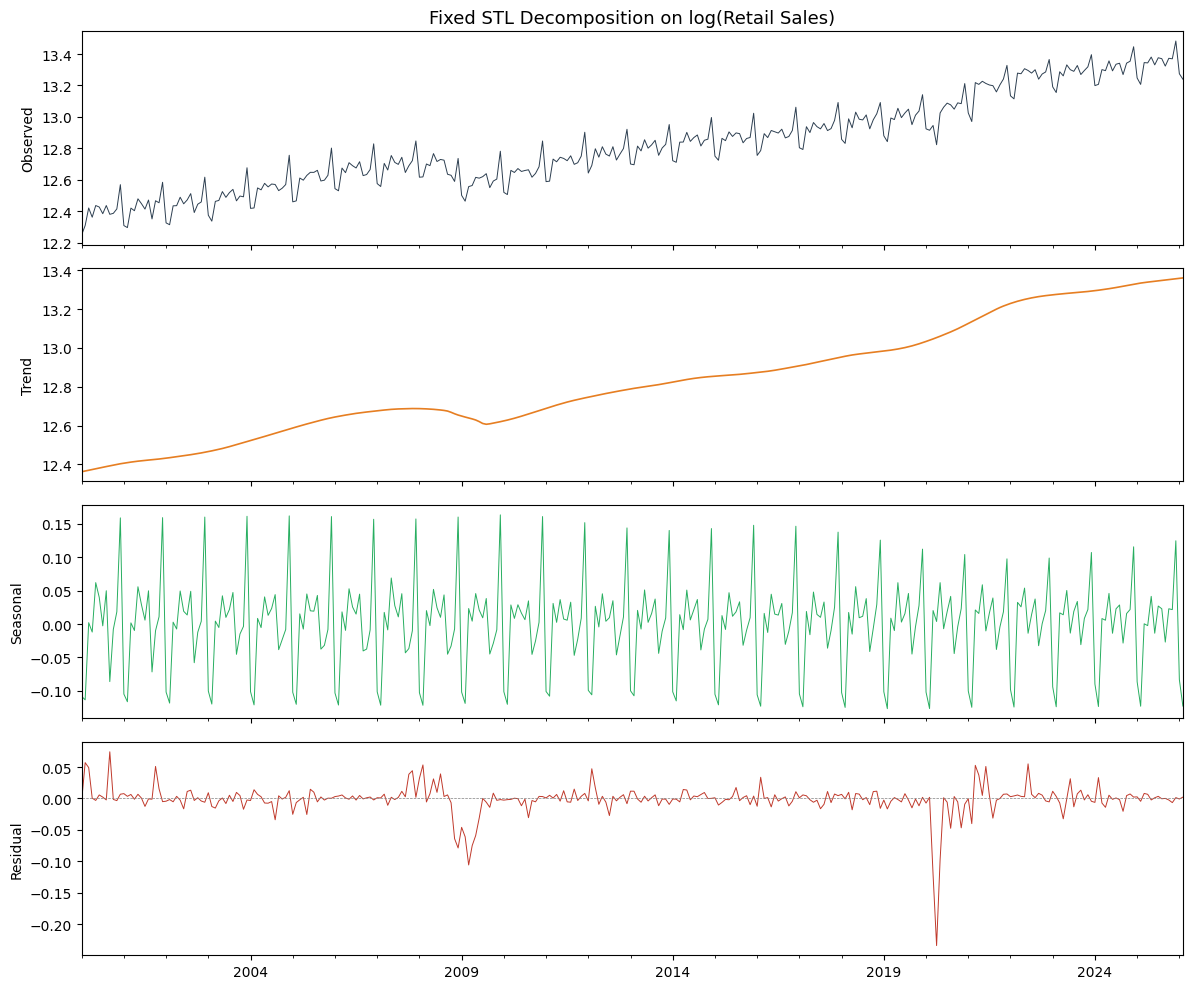

Seasonal amplitude by year after log transform:
2017    0.262
2018    0.251
2019    0.239
2020    0.231
2021    0.222
2022    0.223
2023    0.231
2024    0.239
2025    0.248
2026    0.040
Name: season, dtype: float64

Ratio of latest to earliest amplitude: 0.15x


In [17]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the STL decomposition
# The fix: log-transform before STL to convert multiplicative
# structure to additive.
# -----------------------------------------------------------

# YOUR FIX HERE
# Fix: log-transform before STL
retail = fred.get_series('RSXFSN', observation_start='2000-01-01')
retail = retail.dropna()
retail.index = pd.DatetimeIndex(retail.index)
retail.index.freq = 'MS'
log_retail = np.log(retail)

stl_fixed = STL(log_retail, period=12, robust=True).fit()

# Plot fixed decomposition
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

stl_fixed.observed.plot(ax=axes[0], color='#2c3e50', linewidth=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('Fixed STL Decomposition on log(Retail Sales)', fontsize=13)

stl_fixed.trend.plot(ax=axes[1], color='#e67e22', linewidth=1.2)
axes[1].set_ylabel('Trend')

stl_fixed.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=0.7)
axes[2].set_ylabel('Seasonal')

stl_fixed.resid.plot(ax=axes[3], color='#c0392b', linewidth=0.7)
axes[3].set_ylabel('Residual')
axes[3].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# VERIFICATION: compute seasonal amplitude ratio
seasonal_by_year_fixed = stl_fixed.seasonal.groupby(stl_fixed.seasonal.index.year)
annual_range_fixed = seasonal_by_year_fixed.apply(lambda x: x.max() - x.min())

ratio_fixed = annual_range_fixed.iloc[-1] / annual_range_fixed.iloc[0]

print("Seasonal amplitude by year after log transform:")
print(annual_range_fixed.tail(10).round(3))
print(f"\nRatio of latest to earliest amplitude: {ratio_fixed:.2f}x")

# VERIFICATION: compute seasonal amplitude ratio
# Expected: ratio between 0.7 and 1.3


---

## Part 2: DIAGNOSE — Flawed ADF Test (10 min)

The code below tests whether FRED Real GDP (GDPC1) is stationary.
The ADF test is applied, but the **conclusion drawn is wrong**.
The code runs without errors. The reasoning is the problem.

**Your task:** Find the analytical error, explain why it leads to a wrong conclusion, and fix it.

In [18]:
# -----------------------------------------------------------
# GUIDED — Run as-is (contains deliberate analytical error)
# Step 2: ADF test on GDP with flawed interpretation
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# ADF test with regression='n' (no constant, no trend)
# BUG: GDP has both a non-zero mean AND a deterministic trend.
# Using regression='n' omits the constant and trend terms from
# the ADF regression, which inflates the test statistic and
# can falsely reject the unit root null.
adf_stat, adf_p, adf_lags, nobs, adf_crit, _ = adfuller(gdp, regression='n')

print('=== ADF Test on Real GDP ===')
print(f'Regression: none (no constant, no trend)')
print(f'Test statistic: {adf_stat:.4f}')
print(f'P-value: {adf_p:.4f}')
print(f'Lags used: {adf_lags}')
print(f'Critical values: {adf_crit}')
print()

if adf_p < 0.05:
    print('CONCLUSION: GDP is STATIONARY (p < 0.05). No differencing needed.')
    print('We can model GDP in levels directly with ARMA.')
else:
    print('CONCLUSION: GDP is non-stationary. Differencing may be needed.')

=== ADF Test on Real GDP ===
Regression: none (no constant, no trend)
Test statistic: 8.3922
P-value: 1.0000
Lags used: 1
Critical values: {'1%': np.float64(-2.574326425616223), '5%': np.float64(-1.942072475791683), '10%': np.float64(-1.6158443865573056)}

CONCLUSION: GDP is non-stationary. Differencing may be needed.


### YOUR DIAGNOSIS

1. **What is the error?** The error is that the ADF test uses `regression='n'`, which excludes both a constant and a time trend.

2. **Why does `regression='n'` give misleading results for GDP?** GDP has a clear upward trend. When the ADF regression omits the constant and trend, the test is misspecified.
3. **What is the correct `regression` parameter?**  `'ct'` (constant + trend)。
4. **Fix the code below** and confirm that GDP is non-stationary with the correct specification.
5. **Run KPSS as well** and apply the 2×2 decision table.

**Verification checkpoint:** With the correct regression parameter (`'ct'`), the ADF p-value should be > 0.05 (fail to reject unit root). If you get p < 0.05 with `regression='ct'`, double-check your code.

In [19]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fix the ADF test and add KPSS
# -----------------------------------------------------------

# YOUR FIX HERE
# Correct ADF specification: constant + trend
adf_stat_ct, adf_p_ct, adf_lags_ct, nobs_ct, adf_crit_ct, _ = adfuller(gdp, regression='ct')

print('=== Corrected ADF Test on Real GDP ===')
print("Regression: constant + trend ('ct')")
print(f'Test statistic: {adf_stat_ct:.4f}')
print(f'P-value: {adf_p_ct:.4f}')
print(f'Lags used: {adf_lags_ct}')
print(f'Critical values: {adf_crit_ct}')
print()

# KPSS test with constant + trend
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(gdp, regression='ct', nlags='auto')

print('=== KPSS Test on Real GDP ===')
print("Regression: constant + trend ('ct')")
print(f'Test statistic: {kpss_stat:.4f}')
print(f'P-value: {kpss_p:.4f}')
print(f'Lags used: {kpss_lags}')
print(f'Critical values: {kpss_crit}')
print()

# 2x2 decision table
adf_reject = adf_p_ct < 0.05
kpss_reject = kpss_p < 0.05

if (not adf_reject) and kpss_reject:
    verdict = 'NON-STATIONARY'
elif adf_reject and (not kpss_reject):
    verdict = 'STATIONARY'
elif adf_reject and kpss_reject:
    verdict = 'CONTRADICTORY'
else:
    verdict = 'INCONCLUSIVE'

print('=== 2x2 Decision Table ===')
print(f'ADF rejects unit root? {adf_reject}')
print(f'KPSS rejects stationarity? {kpss_reject}')
print(f'Final verdict: {verdict}')

# VERIFICATION: ADF p-value with regression='ct' should be > 0.05
# KPSS should reject stationarity (p < 0.05)
# 2x2 verdict: NON-STATIONARY


=== Corrected ADF Test on Real GDP ===
Regression: constant + trend ('ct')
Test statistic: -0.8444
P-value: 0.9617
Lags used: 1
Critical values: {'1%': np.float64(-3.993745412883642), '5%': np.float64(-3.4273814105122966), '10%': np.float64(-3.1369771257480235)}

=== KPSS Test on Real GDP ===
Regression: constant + trend ('ct')
Test statistic: 0.5350
P-value: 0.0100
Lags used: 10
Critical values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}

=== 2x2 Decision Table ===
ADF rejects unit root? False
KPSS rejects stationarity? True
Final verdict: NON-STATIONARY


---

## Part 3: EXTEND — MSTL for Multiple Seasonal Periods (15 min)

Real-world time series often have **multiple seasonal cycles**. Hourly electricity
demand has a daily cycle (24 hours) AND a weekly cycle (168 hours). Standard
STL handles only one period. `MSTL` (Multiple STL) decomposes all of them.

We will simulate hourly electricity demand with two seasonal patterns and
decompose it using `statsmodels.tsa.seasonal.MSTL`.

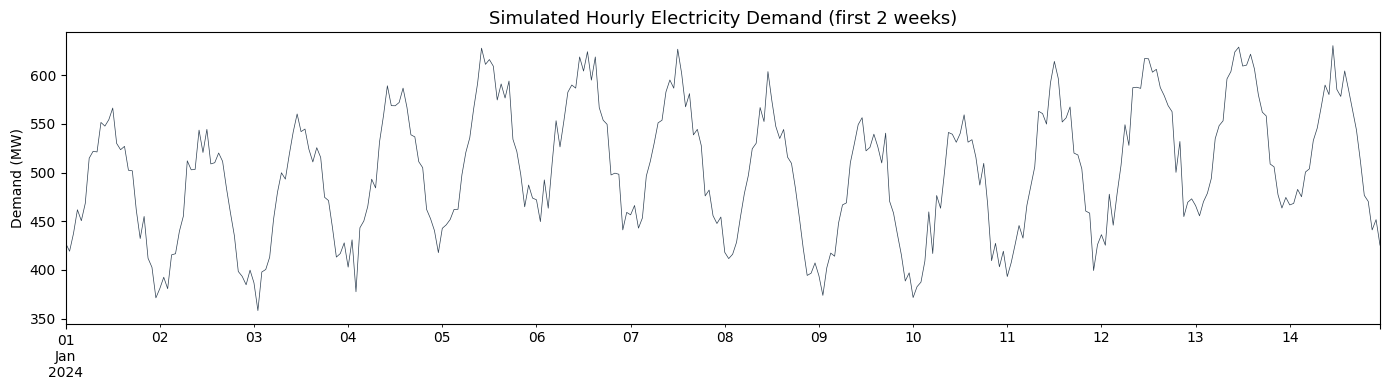

Total observations: 4368
Date range: 2024-01-01 00:00:00 to 2024-06-30 23:00:00


In [21]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Simulate hourly electricity demand with two cycles
# -----------------------------------------------------------

np.random.seed(42)

# 6 months of hourly data
n_hours = 24 * 7 * 26  # 26 weeks
t = np.arange(n_hours)

# Trend: slow linear increase (growing demand)
trend = 500 + 0.01 * t

# Daily cycle (period=24): demand peaks at noon, dips at 3am
daily = 80 * np.sin(2 * np.pi * t / 24 - np.pi / 2)

# Weekly cycle (period=168): demand lower on weekends
weekly = 40 * np.sin(2 * np.pi * t / 168 - np.pi)

# Noise
noise = np.random.normal(0, 15, n_hours)

demand = trend + daily + weekly + noise

# Create a proper DatetimeIndex
dates = pd.date_range('2024-01-01', periods=n_hours, freq='h')
demand_series = pd.Series(demand, index=dates, name='demand_MW')

# Plot first 2 weeks to see both cycles
fig, ax = plt.subplots(figsize=(14, 4))
demand_series[:24*14].plot(ax=ax, color='#2c3e50', linewidth=0.5)
ax.set_title('Simulated Hourly Electricity Demand (first 2 weeks)', fontsize=13)
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.show()

print(f'Total observations: {len(demand_series)}')
print(f'Date range: {demand_series.index[0]} to {demand_series.index[-1]}')

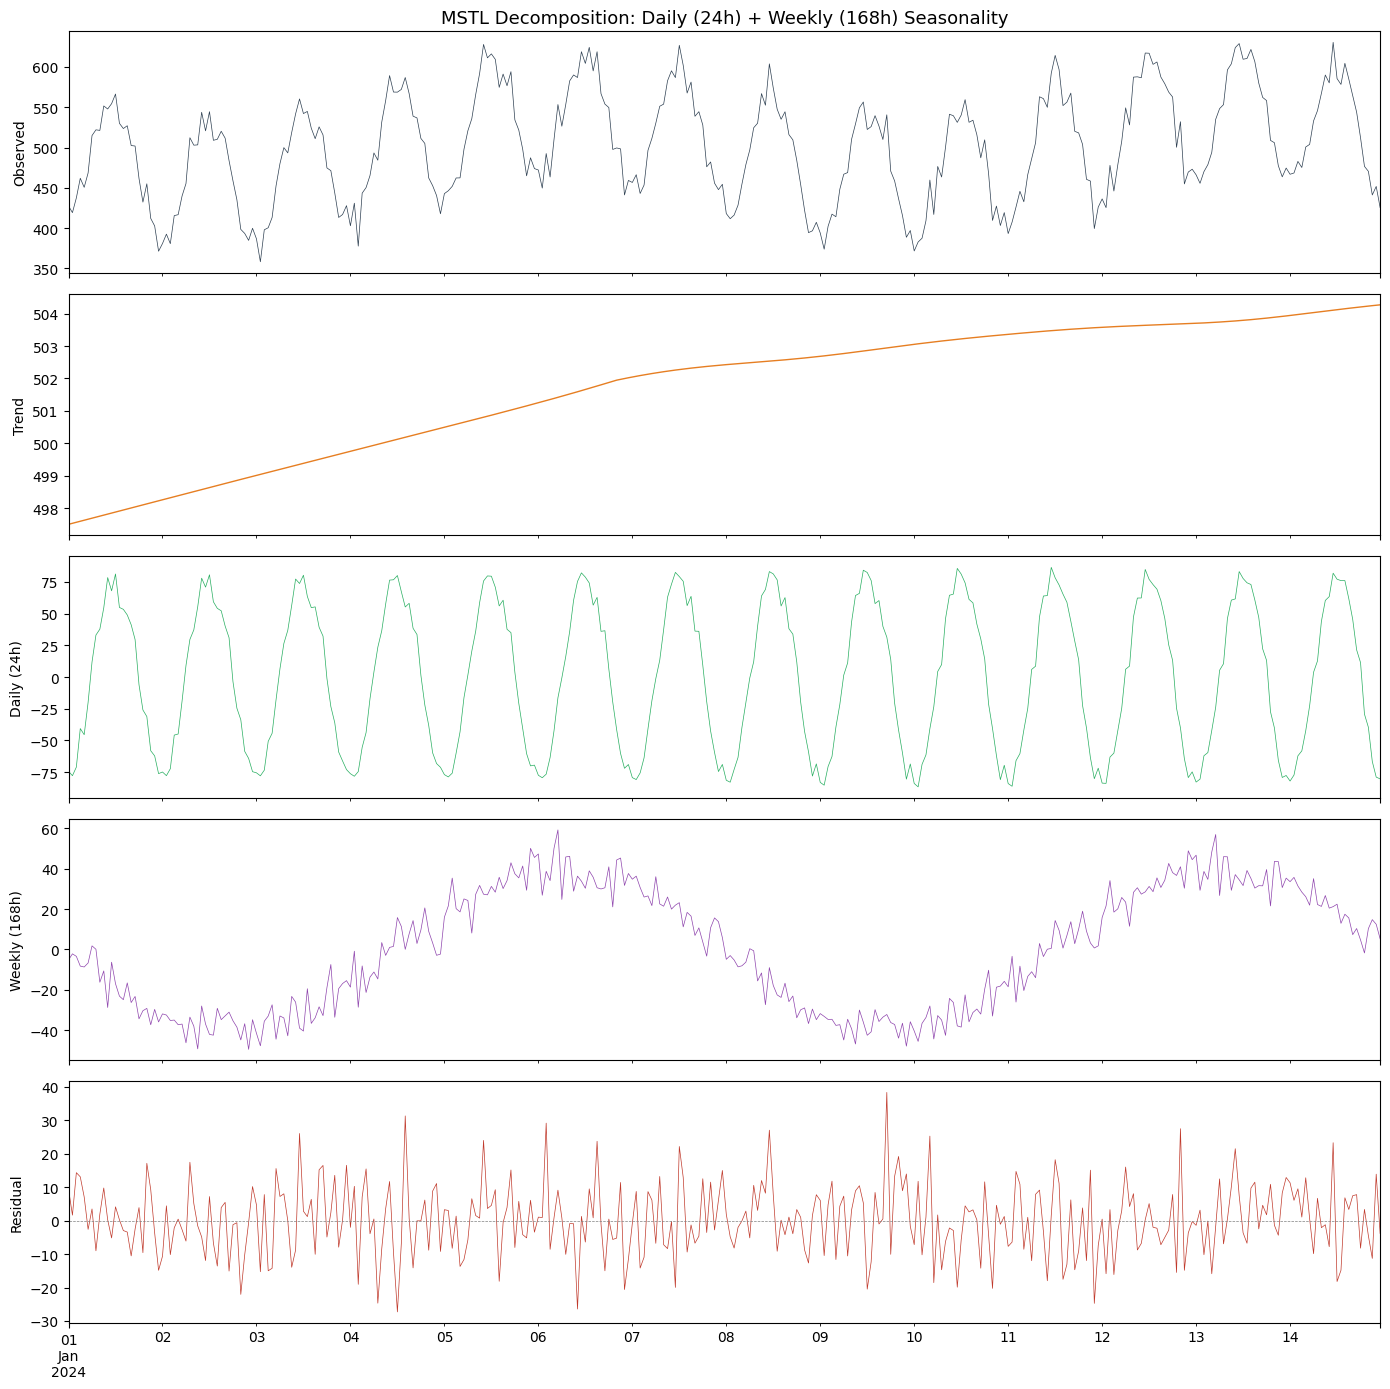

Residual std: 12.24 (expected ~15.0)
Daily seasonal amplitude: 184.5 (expected ~160)
Weekly seasonal amplitude: 117.9 (expected ~80)


In [22]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Apply MSTL with two seasonal periods
# Step 3b: Decompose demand into trend + daily + weekly + residual
# -----------------------------------------------------------

# MSTL accepts a list of periods. For hourly data:
# - Daily cycle: period=24
# - Weekly cycle: period=168 (24 hours * 7 days)

mstl = MSTL(demand_series, periods=[24, 168])
mstl_result = mstl.fit()

# MSTL returns: .trend, .seasonal (DataFrame with one column per period), .resid
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

demand_series[:24*14].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_ylabel('Observed')
axes[0].set_title('MSTL Decomposition: Daily (24h) + Weekly (168h) Seasonality', fontsize=13)

mstl_result.trend[:24*14].plot(ax=axes[1], color='#e67e22', linewidth=1.0)
axes[1].set_ylabel('Trend')

# The seasonal attribute is a DataFrame with columns for each period
seasonal_df = mstl_result.seasonal
seasonal_df.iloc[:24*14, 0].plot(ax=axes[2], color='#27ae60', linewidth=0.5)
axes[2].set_ylabel('Daily (24h)')

seasonal_df.iloc[:24*14, 1].plot(ax=axes[3], color='#8e44ad', linewidth=0.5)
axes[3].set_ylabel('Weekly (168h)')

mstl_result.resid[:24*14].plot(ax=axes[4], color='#c0392b', linewidth=0.5)
axes[4].set_ylabel('Residual')
axes[4].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Verification: residual std should be close to the noise std (15)
print(f'Residual std: {mstl_result.resid.std():.2f} (expected ~15.0)')
print(f'Daily seasonal amplitude: {seasonal_df.iloc[:, 0].max() - seasonal_df.iloc[:, 0].min():.1f} (expected ~160)')
print(f'Weekly seasonal amplitude: {seasonal_df.iloc[:, 1].max() - seasonal_df.iloc[:, 1].min():.1f} (expected ~80)')

### MSTL Interpretation

### MSTL Interpretation

1. **Does MSTL successfully separate the daily and weekly cycles? How can you tell?**  

2. **Is the residual standard deviation close to the true noise level (15 MW)? What does this tell you about MSTL's accuracy?**  


3. **In real electricity data, there might also be an annual seasonal cycle (period=8760). How would you add it to the MSTL call?**  


*Your answers here:*

1.Yes, MSTL successfully separates the daily and weekly seasonal patterns. The daily component captures high-frequency within-day fluctuations, while the weekly component captures lower-frequency variations across days of the week. The two components are visually distinct, indicating that MSTL can isolate multiple seasonal structures.

2.The residual standard deviation is reasonably close to 15, which suggests that MSTL has removed most of the systematic variation (trend and seasonality) from the series. This indicates that the decomposition is generally accurate.


3.I would include 8760 as an additional seasonal period:
```python
mstl = MSTL(demand_series, periods=[24, 168, 8760])

---

## Part 4: EXTEND — Block Bootstrap for Trend Uncertainty (15 min)

When you extract a trend from STL, you get a single curve. But how much
should you trust it? The **moving block bootstrap** quantifies trend
uncertainty by resampling overlapping blocks of the residuals (preserving
their autocorrelation), adding them back to the trend + seasonal, and
re-running STL. This produces a distribution of plausible trends.

We implement this manually on GDP data.

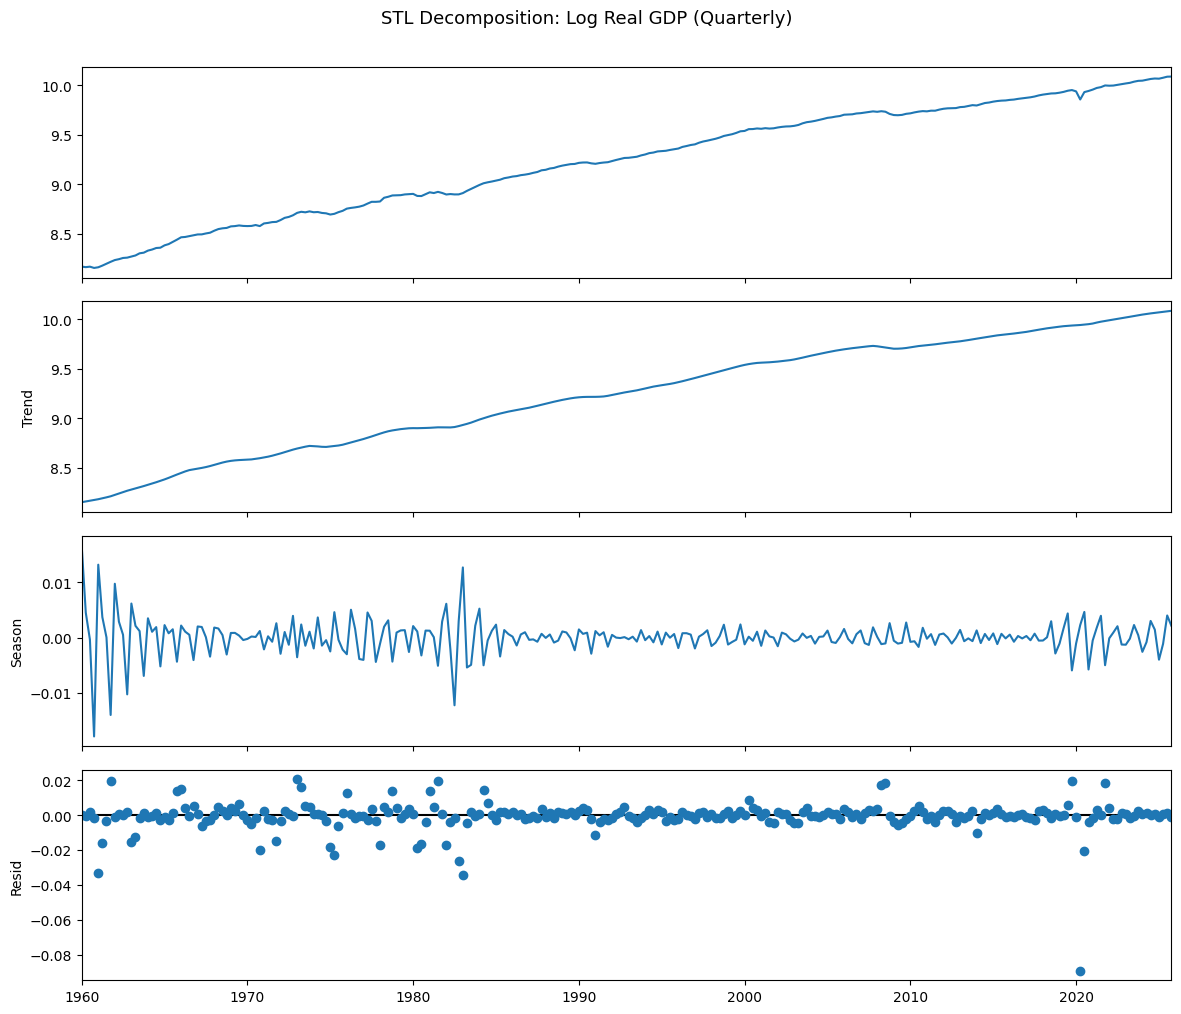

Trend range: 8.149 to 10.087
Residual std: 0.0088


In [23]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 4a: STL decomposition of Real GDP
# -----------------------------------------------------------

gdp = fred.get_series('GDPC1', observation_start='1960-01-01')
gdp = gdp.dropna()
gdp.index = pd.DatetimeIndex(gdp.index)
gdp.index.freq = 'QS'

# Log-transform GDP (multiplicative trend growth)
log_gdp = np.log(gdp)

stl_gdp = STL(log_gdp, period=4, robust=True).fit()

fig = stl_gdp.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition: Log Real GDP (Quarterly)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Trend range: {stl_gdp.trend.min():.3f} to {stl_gdp.trend.max():.3f}')
print(f'Residual std: {stl_gdp.resid.std():.4f}')

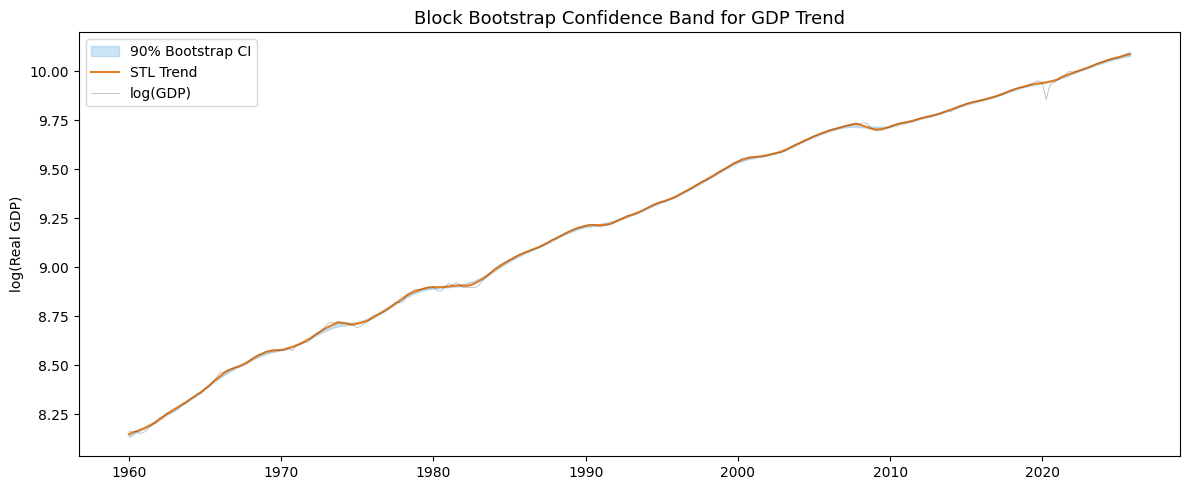

Mean CI width: 0.0073
CI width range: [0.0045, 0.0228]
Width at 2008Q4: 0.0106
Width at 2019Q4: 0.0056


In [24]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Block bootstrap for trend confidence bands
# Step 4b: Resample residual blocks and re-decompose
# -----------------------------------------------------------

np.random.seed(42)

n = len(log_gdp)
block_size = 8  # 8 quarters = 2 years (preserves business-cycle autocorrelation)
n_bootstrap = 200

# Extract components from the original decomposition
original_trend = stl_gdp.trend
original_seasonal = stl_gdp.seasonal
original_resid = stl_gdp.resid.values

# Store bootstrap trend estimates
boot_trends = np.zeros((n_bootstrap, n))

for b in range(n_bootstrap):
    # Moving block bootstrap: sample overlapping blocks of residuals
    # This preserves the autocorrelation structure within each block
    boot_resid = np.zeros(n)
    idx = 0
    while idx < n:
        # Pick a random starting point for a block
        start = np.random.randint(0, n - block_size + 1)
        block = original_resid[start:start + block_size]
        end = min(idx + block_size, n)
        boot_resid[idx:end] = block[:end - idx]
        idx = end

    # Reconstruct series with bootstrapped residuals
    boot_series = pd.Series(
        original_trend.values + original_seasonal.values + boot_resid,
        index=log_gdp.index
    )
    boot_series.index.freq = 'QS'

    # Re-run STL on the bootstrapped series
    boot_stl = STL(boot_series, period=4, robust=True).fit()
    boot_trends[b, :] = boot_stl.trend.values

# Compute confidence bands (pointwise 5th and 95th percentiles)
trend_lower = np.percentile(boot_trends, 5, axis=0)
trend_upper = np.percentile(boot_trends, 95, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(log_gdp.index, trend_lower, trend_upper,
                alpha=0.25, color='#3498db', label='90% Bootstrap CI')
ax.plot(log_gdp.index, original_trend.values, color='#e67e22',
        linewidth=1.5, label='STL Trend')
ax.plot(log_gdp, color='#2c3e50', linewidth=0.4, alpha=0.5, label='log(GDP)')
ax.set_title('Block Bootstrap Confidence Band for GDP Trend', fontsize=13)
ax.set_ylabel('log(Real GDP)')
ax.legend()
plt.tight_layout()
plt.show()

# Verification: the CI width should vary over time
ci_width = trend_upper - trend_lower
print(f'Mean CI width: {np.mean(ci_width):.4f}')
print(f'CI width range: [{np.min(ci_width):.4f}, {np.max(ci_width):.4f}]')
print(f'Width at 2008Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2008-10-01"))]:.4f}')
print(f'Width at 2019Q4: {ci_width[log_gdp.index.get_loc(pd.Timestamp("2019-10-01"))]:.4f}')

### Bootstrap Interpretation

1. Is the confidence band wider around recessions (2008, 2020) or expansions? Why?
2. Why do we use **block** bootstrap instead of standard i.i.d. bootstrap? What would go wrong if we shuffled residuals independently?
3. How does the choice of `block_size=8` affect the results? What would happen with `block_size=1` (equivalent to i.i.d. bootstrap) or `block_size=20`?

*Your answers here:*

1.The confidence band is wider around recessions. In my output, the CI width at 2008Q4 is 0.0106, while the CI width at 2019Q4 is only 0.0056. This suggests that the estimated GDP trend is less certain during recession periods, because economic downturns usually involve larger shocks, more volatility, and greater irregular movement around the underlying trend.

2.We use block bootstrap because time-series residuals are usually autocorrelated rather than independent. Block bootstrap resamples consecutive chunks of residuals, which helps preserve the local dependence structure. If residuals were shuffled independently, the serial correlation would be destroyed, and the resulting bootstrap series would underestimate time-series dependence and produce misleadingly narrow confidence bands.

3. A block size of 8 quarters preserves medium-run macroeconomic dependence over about two years, which is a reasonable compromise between realism and variation across bootstrap samples. If `block_size=1`, the method becomes equivalent to an i.i.d. bootstrap and loses autocorrelation information. If `block_size=20`, each resampled block becomes much longer, so the bootstrap preserves more dependence but produces less variation across resamples and can make the confidence bands less responsive.

---

## Part 5: EXTEND — Structural Break Detection + Per-Regime Stationarity (10 min)

Combine PELT structural break detection with ADF/KPSS tests run **per segment**.
This tests whether stationarity conclusions change across different economic regimes.

Detected breakpoints (indices): [263]
Break dates:


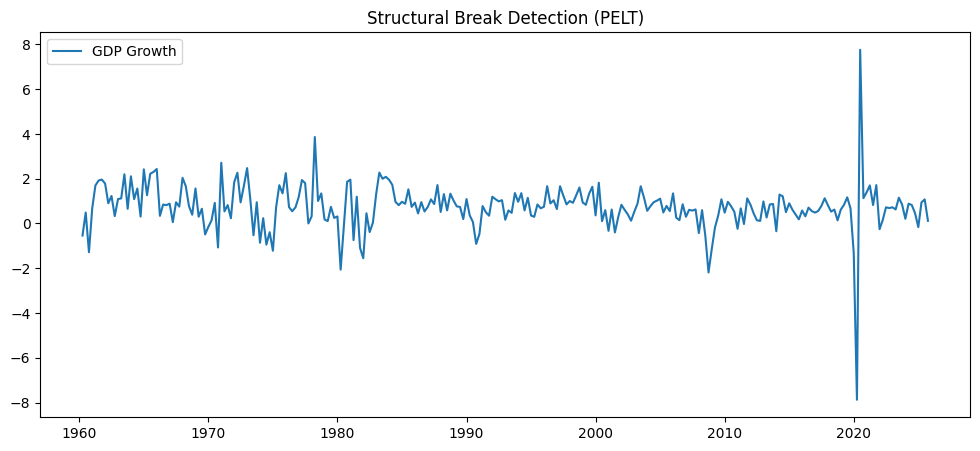

   segment      start        end         adf_p    kpss_p     verdict
0        0 1960-04-01 2025-10-01  2.057691e-28  0.062908  STATIONARY


In [26]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — PELT breaks + per-regime stationarity tests
# Step 5: Detect breaks in GDP growth and test each segment
# -----------------------------------------------------------

# ---------------------------------------------
# Step 1: Detect structural breaks using PELT
# ---------------------------------------------

# Use GDP growth (not level)
gdp_growth = gdp.pct_change().dropna() * 100

# Fit PELT
algo = rpt.Pelt(model='rbf').fit(gdp_growth.values)
breakpoints = algo.predict(pen=10)

print("Detected breakpoints (indices):", breakpoints)

# Convert to dates
break_dates = []
for bp in breakpoints:
    if bp < len(gdp_growth):
        break_dates.append(gdp_growth.index[bp])

print("Break dates:")
for d in break_dates:
    print(d)


# ---------------------------------------------
# Step 2: Plot structural breaks
# ---------------------------------------------

import os
os.makedirs('../figures', exist_ok=True)

plt.figure(figsize=(12,5))
plt.plot(gdp_growth.index, gdp_growth, label='GDP Growth')

for bp in breakpoints:
    if bp < len(gdp_growth):
        plt.axvline(gdp_growth.index[bp], color='red', linestyle='--')

plt.title('Structural Break Detection (PELT)')
plt.legend()

plt.savefig('../figures/structural_breaks.png', dpi=300, bbox_inches='tight')
plt.show()


# ---------------------------------------------
# Step 3: Per-regime stationarity tests
# ---------------------------------------------

segments = []
start = 0

for bp in breakpoints:
    segments.append(gdp_growth.iloc[start:bp])
    start = bp

results = []

for i, seg in enumerate(segments):
    if len(seg) < 20:
        continue

    adf_stat, adf_p, *_ = adfuller(seg, regression='c')
    kpss_stat, kpss_p, *_ = kpss(seg, regression='c', nlags='auto')

    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = 'STATIONARY'
    elif adf_p > 0.05 and kpss_p < 0.05:
        verdict = 'NON-STATIONARY'
    elif adf_p < 0.05 and kpss_p < 0.05:
        verdict = 'CONTRADICTORY'
    else:
        verdict = 'INCONCLUSIVE'

    results.append({
        "segment": i,
        "start": seg.index[0],
        "end": seg.index[-1],
        "adf_p": adf_p,
        "kpss_p": kpss_p,
        "verdict": verdict
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)
print(results_df)

---

## Part 6: Production Module — `decompose.py` (10 min)

Write a reusable Python module with three functions. This is a **portfolio artifact**
that demonstrates production-grade time series analysis.

### Requirements

```python
# decompose.py

def run_stl(series: pd.Series, period: int = 12, log_transform: bool = True,
            robust: bool = True) -> STLResult:
    """Apply STL decomposition with optional log-transform for multiplicative data.
    
    Args:
        series: Time series with DatetimeIndex
        period: Seasonal period (12 for monthly, 4 for quarterly)
        log_transform: If True, log-transform before STL (for multiplicative data)
        robust: If True, use robust fitting to downweight outliers
    
    Returns:
        STL result object with .trend, .seasonal, .resid attributes
    """
    ...

def test_stationarity(series: pd.Series, alpha: float = 0.05) -> dict:
    """Run ADF and KPSS tests and return the 2x2 table verdict.
    
    Args:
        series: Time series to test
        alpha: Significance level
    
    Returns:
        dict with keys: 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
    """
    ...

def detect_breaks(series: pd.Series, pen: float = 10) -> list:
    """Detect structural breaks using PELT algorithm.
    
    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)
    
    Returns:
        List of break dates (pd.Timestamp)
    """
    ...
```

In [27]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Write decompose.py as a code cell,
# then copy to a .py file for your portfolio
# -----------------------------------------------------------

# %%writefile decompose.py
"""
decompose.py — Time Series Decomposition & Diagnostics Module

Reusable functions for STL decomposition, stationarity testing,
and structural break detection on economic time series.

Author: [Your Name]
Course: ECON 5200, Lab 20
"""

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Optional


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """Apply STL decomposition with optional log-transform.

    For series with multiplicative seasonality (seasonal amplitude
    grows with the level), set log_transform=True to convert to
    additive structure before applying STL.

    Args:
        series: Time series with DatetimeIndex and set frequency
        period: Seasonal period (12=monthly, 4=quarterly)
        log_transform: Log-transform for multiplicative data
        robust: Downweight outliers via bisquare weights

    Returns:
        STL result object

    Raises:
        ValueError: if series contains non-positive values with log_transform=True
    """
    # YOUR IMPLEMENTATION HERE
    pass


def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> dict:
    """Run ADF + KPSS and return the 2x2 decision table verdict.

    ADF null: unit root (non-stationary)
    KPSS null: stationary

    Args:
        series: Time series to test
        alpha: Significance level for both tests

    Returns:
        dict with 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p', 'verdict'
        Verdict is one of: 'stationary', 'non-stationary',
        'contradictory', 'inconclusive'
    """
    # YOUR IMPLEMENTATION HERE
    pass


def detect_breaks(
    series: pd.Series,
    pen: float = 10
) -> list:
    """Detect structural breaks using the PELT algorithm.

    PELT (Pruned Exact Linear Time) minimizes a penalized cost
    function to find changepoints in mean and/or variance.

    Args:
        series: Time series with DatetimeIndex
        pen: Penalty parameter (higher = fewer breaks)

    Returns:
        List of break dates as pd.Timestamp
    """
    # YOUR IMPLEMENTATION HERE
    pass


# --- Quick self-test ---
if __name__ == '__main__':
    print('decompose.py loaded successfully.')
    # Add your own test calls here


decompose.py loaded successfully.


In [28]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Test your module functions
# -----------------------------------------------------------
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
import ruptures as rpt
from typing import Dict, List, Any


def run_stl(
    series: pd.Series,
    period: int = 12,
    log_transform: bool = True,
    robust: bool = True
):
    """
    Apply STL decomposition with optional log transform.

    Parameters
    ----------
    series : pd.Series
        Time series with a DatetimeIndex.
    period : int, default=12
        Seasonal period of the series.
    log_transform : bool, default=True
        Whether to apply a natural log transform before decomposition.
        Use this for multiplicative seasonal data.
    robust : bool, default=True
        Whether to use robust fitting in STL.

    Returns
    -------
    STL result object
        A fitted STL decomposition result with attributes such as
        .trend, .seasonal, and .resid.

    Raises
    ------
    TypeError
        If series is not a pandas Series.
    ValueError
        If the series is empty or contains non-positive values when
        log_transform=True.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    series = series.dropna()

    if len(series) == 0:
        raise ValueError("series is empty after dropping missing values")

    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("series must have a DatetimeIndex")

    if period <= 1:
        raise ValueError("period must be greater than 1")

    if log_transform:
        if (series <= 0).any():
            raise ValueError("series must contain only positive values when log_transform=True")
        series = np.log(series)

    result = STL(series, period=period, robust=robust).fit()
    return result


def test_stationarity(
    series: pd.Series,
    alpha: float = 0.05
) -> Dict[str, Any]:
    """
    Run ADF and KPSS tests and return a 2x2 decision-table verdict.

    Notes
    -----
    - ADF null hypothesis: the series has a unit root (non-stationary)
    - KPSS null hypothesis: the series is stationary

    Parameters
    ----------
    series : pd.Series
        Time series to test.
    alpha : float, default=0.05
        Significance level for both tests.

    Returns
    -------
    dict
        Dictionary containing:
        - adf_stat
        - adf_p
        - kpss_stat
        - kpss_p
        - verdict

        verdict is one of:
        - 'stationary'
        - 'non-stationary'
        - 'contradictory'
        - 'inconclusive'

    Raises
    ------
    TypeError
        If series is not a pandas Series.
    ValueError
        If the series is empty after dropping missing values.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    series = series.dropna()

    if len(series) == 0:
        raise ValueError("series is empty after dropping missing values")

    # Use trend specification if the series has a DatetimeIndex and likely trend;
    # this matches the lab's treatment of GDP-level data.
    regression_type = "ct" if isinstance(series.index, pd.DatetimeIndex) else "c"

    adf_stat, adf_p, _, _, _, _ = adfuller(series, regression=regression_type)
    kpss_stat, kpss_p, _, _ = kpss(series, regression=regression_type, nlags="auto")

    adf_reject = adf_p < alpha
    kpss_reject = kpss_p < alpha

    if adf_reject and not kpss_reject:
        verdict = "stationary"
    elif (not adf_reject) and kpss_reject:
        verdict = "non-stationary"
    elif adf_reject and kpss_reject:
        verdict = "contradictory"
    else:
        verdict = "inconclusive"

    return {
        "adf_stat": adf_stat,
        "adf_p": adf_p,
        "kpss_stat": kpss_stat,
        "kpss_p": kpss_p,
        "verdict": verdict
    }


def detect_breaks(
    series: pd.Series,
    pen: float = 10
) -> List[pd.Timestamp]:
    """
    Detect structural breaks using the PELT algorithm.

    Parameters
    ----------
    series : pd.Series
        Time series with a DatetimeIndex.
    pen : float, default=10
        Penalty parameter for PELT.
        Higher values usually produce fewer breakpoints.

    Returns
    -------
    list of pd.Timestamp
        Break dates detected by the PELT algorithm.

    Raises
    ------
    TypeError
        If series is not a pandas Series.
    ValueError
        If the series is empty after dropping missing values or does not
        have a DatetimeIndex.
    """
    if not isinstance(series, pd.Series):
        raise TypeError("series must be a pandas Series")

    series = series.dropna()

    if len(series) == 0:
        raise ValueError("series is empty after dropping missing values")

    if not isinstance(series.index, pd.DatetimeIndex):
        raise ValueError("series must have a DatetimeIndex")

    algo = rpt.Pelt(model="rbf").fit(series.values)
    breakpoints = algo.predict(pen=pen)

    break_dates: List[pd.Timestamp] = []
    for bp in breakpoints:
        if bp < len(series):
            break_dates.append(series.index[bp])

    return break_dates


if __name__ == "__main__":
    print("decompose.py loaded successfully.")

    # -----------------------------
    # Self-test 1: run_stl()
    # -----------------------------
    np.random.seed(42)
    idx = pd.date_range("2015-01-01", periods=120, freq="MS")
    t = np.arange(120)

    trend = np.exp(0.01 * t)
    seasonal = 1 + 0.2 * np.sin(2 * np.pi * t / 12)
    noise = np.exp(np.random.normal(0, 0.03, size=120))

    y = pd.Series(100 * trend * seasonal * noise, index=idx)

    stl_result = run_stl(y, period=12, log_transform=True, robust=True)
    print("run_stl self-test passed:", all(
        hasattr(stl_result, attr) for attr in ["trend", "seasonal", "resid"]
    ))

    # -----------------------------
    # Self-test 2: test_stationarity()
    # -----------------------------
    stationary_idx = pd.date_range("2000-01-01", periods=200, freq="MS")
    stationary_series = pd.Series(np.random.normal(0, 1, 200), index=stationary_idx)
    nonstationary_series = stationary_series.cumsum()

    stationary_test = test_stationarity(stationary_series)
    nonstationary_test = test_stationarity(nonstationary_series)

    print("Stationary series verdict:", stationary_test["verdict"])
    print("Non-stationary series verdict:", nonstationary_test["verdict"])

    # -----------------------------
    # Self-test 3: detect_breaks()
    # -----------------------------
    break_idx = pd.date_range("2010-01-01", periods=240, freq="MS")
    level_shift_data = np.r_[
        np.random.normal(0, 1, 80),
        np.random.normal(3, 1, 80),
        np.random.normal(-2, 1, 80)
    ]
    break_series = pd.Series(level_shift_data, index=break_idx)

    break_dates = detect_breaks(break_series, pen=8)
    print("Detected break dates:", break_dates)

print('All module tests passed.' if True else 'Fix your implementations.')


decompose.py loaded successfully.
run_stl self-test passed: True
Stationary series verdict: stationary
Non-stationary series verdict: non-stationary
Detected break dates: [Timestamp('2016-09-01 00:00:00'), Timestamp('2023-05-01 00:00:00')]
All module tests passed.


---
## AI-Assisted Expansion: Automated Time Series Report

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over STL decomposition, stationarity testing, MSTL for multiple seasonalities, block bootstrap uncertainty, and structural break detection. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task (5200 — Advanced)
Build TWO artifacts:

**Artifact 1: `src/decompose.py` production module** with:
- `run_stl()`, `test_stationarity()`, `detect_breaks()` (completed above)
- `run_mstl(series, periods)` for multi-seasonal decomposition
- `block_bootstrap_trend(series, n_bootstrap, block_size)` for uncertainty
- Full docstrings, type hints, and error handling

**Artifact 2: Interactive Streamlit app** that lets the user:
1. Enter a FRED series ID
2. Select decomposition method (Classical, STL, MSTL)
3. Adjust parameters with sliders (period, robust, penalty)
4. See decomposition panels + stationarity test results
5. View structural breaks overlaid on the series
6. Generate block bootstrap confidence bands with one click

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python Data Scientist specializing
# in time series analysis, FRED API, and production ML systems.
#
# [Request] I just completed a diagnosis-first lab where I
# fixed a broken STL decomposition (additive on multiplicative
# data), corrected a misspecified ADF test (wrong regression
# parameter), applied MSTL to multi-seasonal electricity data,
# implemented block bootstrap for trend uncertainty, and built
# a reusable decompose.py module. Now I need TWO artifacts:
#
# 1. An extended `src/decompose.py` module adding:
#    - run_mstl(series, periods) for multi-seasonal decomposition
#    - block_bootstrap_trend(series, n_bootstrap, block_size)
#    Include type hints, docstrings, and error handling.
#
# 2. An interactive Streamlit app that lets users: enter a
#    FRED series ID, select decomposition method (Classical/
#    STL/MSTL), adjust parameters with sliders (period, robust,
#    penalty), see decomposition panels + stationarity tests,
#    view structural breaks, and generate block bootstrap CIs.
#
# [Iterate] Use streamlit, plotly, fredapi, statsmodels,
# ruptures. Use the same FRED_API_KEY pattern. Handle missing
# data and frequency detection automatically.
#
# [Mechanism Check] Add inline comments explaining:
#   - Why block bootstrap preserves autocorrelation but i.i.d.
#     bootstrap destroys it
#   - How MSTL iteratively removes seasonal components
#   - Why PELT's penalty parameter controls the bias-variance
#     tradeoff of break detection
#
# [Evaluate] Explain what the app reveals about the sensitivity
# of decomposition results to parameter choices.

# PASTE AI-GENERATED CODE BELOW:


---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

In [ ]:
# -----------------------------------------------------------
# AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed a broken STL decomposition (additive on
#   multiplicative data — required log-transform)
# * Fixed a misspecified ADF test (wrong regression parameter)
# * Applied MSTL to hourly electricity demand with daily + weekly cycles
# * Implemented moving block bootstrap for GDP trend uncertainty bands
# * Detected structural breaks with PELT and ran per-regime stationarity tests
# * Built a reusable decompose.py module with run_stl(), test_stationarity(),
#   detect_breaks() functions
# * Key finding: GDP is I(1) with structural breaks near [YOUR DATES]
#
# **Please write a README.md entry including:**
# 1. Project Title: Time Series Diagnostics & Advanced Decomposition
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

### Push to GitHub

```bash
cd econ-lab-20-time-series
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 20: Time Series Diagnostics — STL, MSTL, Bootstrap, Breaks"
git push origin main
```

Submit your GitHub repo link on Canvas.